# Lineární klasifikace do více tříd pomocí funkce Softmax

Úloha zaměřená na implementaci paralelního lineární klasifikáru pomocí funkce softmax.


### Softmax
- Funkce softmax má c vstupů a c výstupů. 
- Všechny výstupy jsou kladná čísla. 
- Součet všech výstupů dohromady je roven číslu 1.
$$\widehat{y_c} = softmax(u) = \frac{e^{u_c}}{\sum_{d=0}^{c} {e^{u_d}}} $$

Výsledkem klasifikace je třída, pro kterou je hodnota softmaxu nejvyšší.

### Odhad parametrů modelu

Model nemá jeden vektor parametrů $\theta$, ale matici parametrů $\Theta$

Příklad:
- Vektor $x$ má dimenzi 3 (3 příznaky)
- Klasifikujeme do 4 tříd
$$ \Theta^T = 
        \begin{bmatrix}
        [\theta_{00} & \theta_{01} & \theta_{02} & \theta_{03}] \\
        [\theta_{10} & \theta_{11} & \theta_{12} & \theta_{13}] \\
        [\theta_{20} & \theta_{21} & \theta_{22} & \theta_{23}] \\
        [\theta_{30} & \theta_{31} & \theta_{32} & \theta_{33}] \\
        \end{bmatrix}  $$

#### Pomoc sumy:

$$ \Theta_{t+1} = \Theta_{t} - \alpha \sum_{i=0}^{N} {x_i}^T (\widehat{y_i} - y_i) $$
kde $\alpha$ je velikost kroku (learning rate), 

$y_i$ je vektor, obsahující hodnotu 1 na indexu správné třídy: $y_i \in [...0, 0, 1, 0,..]$,

$\widehat{y_i} = softmax(x_i^T \Theta)^T$


#### Pomocí  matice:
Maticová implementace je řádově výpočetně efektivnější.

$$ \Theta_{t+1} = \Theta_{t} - \alpha X^T (\widehat{Y} - Y) $$
$Y$ je matice nul a jedniček dle indexů tříd v datech (one_hot_encoding), 

#### Postup:
1. Parametr $\theta$ (resp. váhy $w$ a bias $b$) se inicializuje na malé náhodné hodnoty
2. Na vstup se přivedou všechna trénovací data a na výstupu se tím pádem objeví posloupnost nul a jedniček (obsahuje chyby)
3. Na základě chyb se upraví hodnoty vah
4. Kroky 2. a 3. se postupně opakují dokud dostatečně klesá chybovost klasifikátoru (nebo podle počtu iteraci)



### Klasifikace pro 2 třídy:


In [95]:
import numpy as np
import usu
import matplotlib.pyplot as plt

def show_loss(iterations, loss, epoch=False):
    plt.plot(iterations, loss)
    plt.xlabel("Epocha" if epoch else "Iterace")
    plt.ylabel("Loss")
    plt.title("Průběh trénování")
    plt.show()

npzfile = np.load('data/data_07_2cl.npz')

data = npzfile['data']
ref = npzfile['ref']
data.shape, ref.shape



((100, 2), (100, 1))

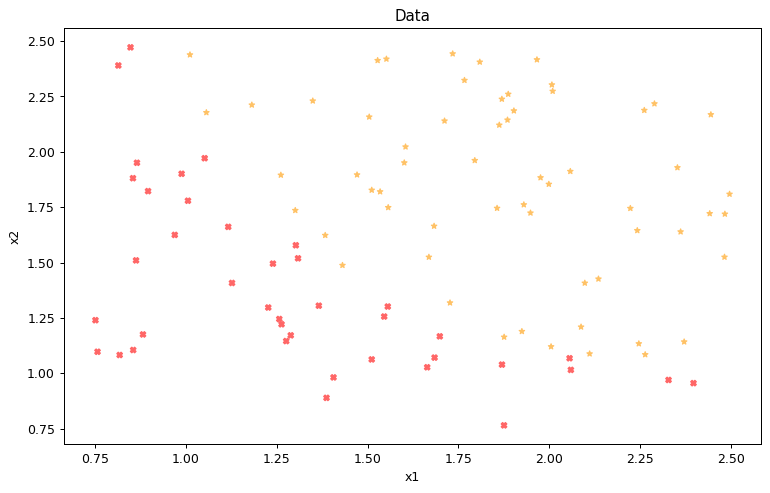

In [96]:
usu.drawSoftmax(data,ref)


In [97]:
def softmax(u):
    """
    vstupem muze byt skalar, vektor, nebo matice 
    """
    #################################################################
    # ZDE DOPLNIT
    
    y = np.exp(u) / np.sum(np.exp(u), axis=0, keepdims=True)
    
    #################################################################
    return y

usu.checkSoftmax(softmax)

True

In [98]:
def computeThetaGD(x, y, alpha=0.01, iterations=1000, plot_loss=False):
    # pro kazdou iteraci vypoctete loss a zapiste ho na odpovidajici index v promenne
    loss = np.zeros(iterations)

    #################################################################
    # ZDE DOPLNIT

    x = np.c_[np.ones((x.shape[0], 1)), x]
    theta = np.random.randn(x.shape[1], np.max(y) + 1) * 0.00001
    new_y = np.zeros((y.shape[0], np.max(y) + 1))
    for i in range(y.shape[0]):
        new_y[i, y[i]] = 1
    y = new_y
    #print((x @ theta).shape, softmax(x @ theta), y.shape)
    for i in range(iterations):
        theta = theta - alpha * x.T @ (softmax((x @ theta).T).T - y)
        loss[i] = -np.sum(y * np.log(softmax((x @ theta).T).T))
    
    #################################################################

    if plot_loss:
        show_loss(np.arange(iterations), loss)

    return theta


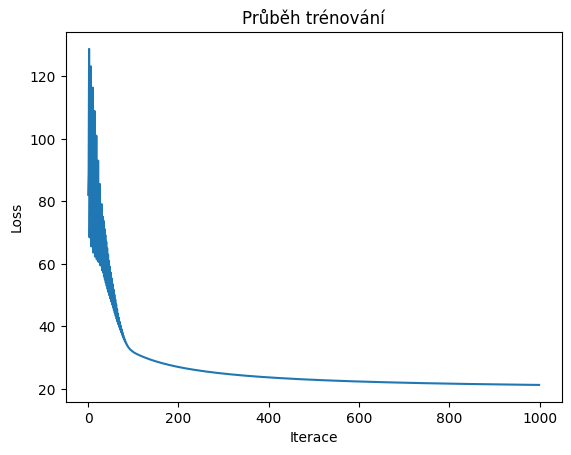

array([[ 9.10850413, -9.1085271 ],
       [-3.01430298,  3.01431061],
       [-2.90413042,  2.90413636]])

In [99]:
theta = computeThetaGD(data, ref, plot_loss=True)
theta

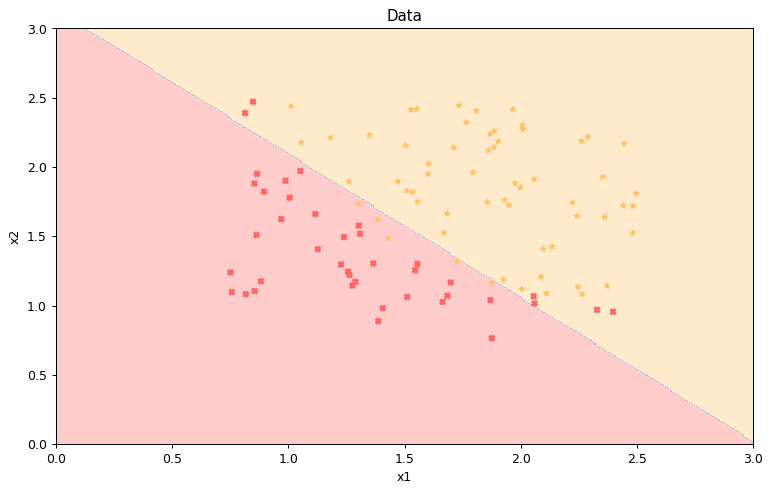

In [100]:
usu.drawSoftmax(data, ref, theta, softmax)


In [101]:
def predict(x,theta):
    #################################################################
    # ZDE DOPLNIT
    x = np.c_[np.ones((x.shape[0], 1)), x]
    classes = np.argmax(x @ theta, axis=1)
    #################################################################
    return classes


In [102]:
x_pred = np.array([[1, 1],[ 2, 2]])
predict(x_pred,theta)


array([0, 1])

### Klasifikace pro více tříd:
#### 3 třídy:


In [103]:
npzfile = np.load('data/data_07_3cl_ez.npz') 

data = npzfile['data']
ref = npzfile['ref']

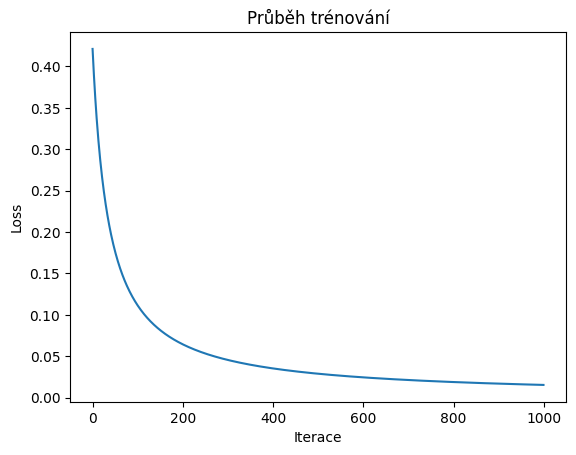

array([[ 5.07683042e-01, -5.03094643e-01, -4.58035824e-03],
       [ 2.72049364e+00,  5.91190413e+00, -8.63238305e+00],
       [-7.47231941e+00,  4.70469044e+00,  2.76763191e+00]])

In [104]:
theta = computeThetaGD(data, ref, plot_loss=True)
theta

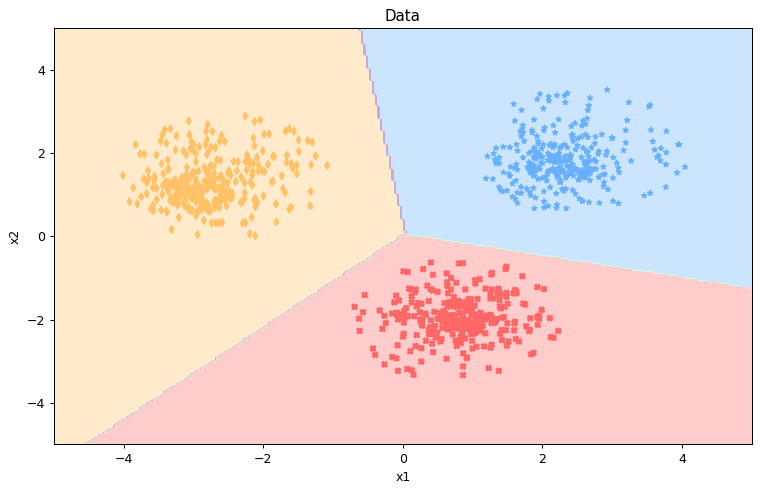

In [105]:
usu.drawSoftmax(data, ref, theta, softmax)


In [106]:
x_pred = np.array([[-3, 1],[ 0, -2],[ 3, 2]])
predict(x_pred,theta)


array([2, 0, 1])

#### 4 třídy:

In [107]:
npzfile = np.load('data/data_07_4cl.npz')

data = npzfile['data']
ref = npzfile['ref']


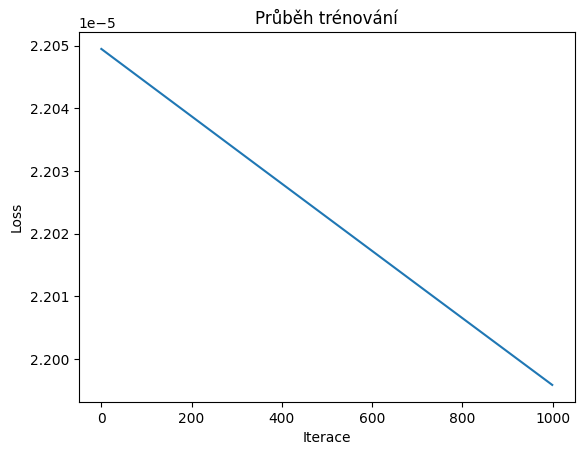

array([[-1.62503402e-04,  1.77753363e-04,  4.80299066e-05,
        -7.07606069e-05],
       [ 8.17573852e+00,  6.92664009e+00, -7.25368476e+00,
        -7.84871416e+00],
       [-6.79695012e+00,  6.90767851e+00, -7.30098613e+00,
         7.19023611e+00]])

In [108]:
theta = computeThetaGD(data, ref, plot_loss=True)
theta

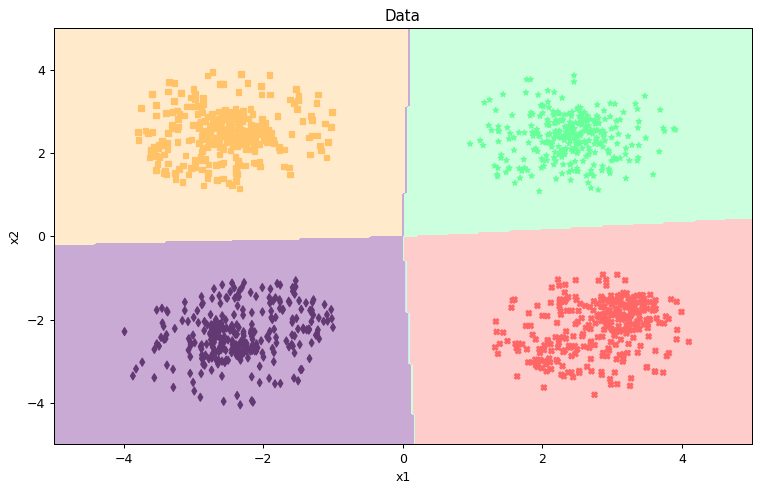

In [109]:
usu.drawSoftmax(data, ref, theta, softmax)


In [110]:
x_pred = np.array([[-3, -1],[ -3, 2],[ 3, -1],[ 3, 2]])
predict(x_pred,theta)


array([2, 3, 0, 1])

#### 5 tříd:

In [111]:
npzfile = np.load('data/data_07_5cl.npz')

data = npzfile['data']
ref = npzfile['ref']


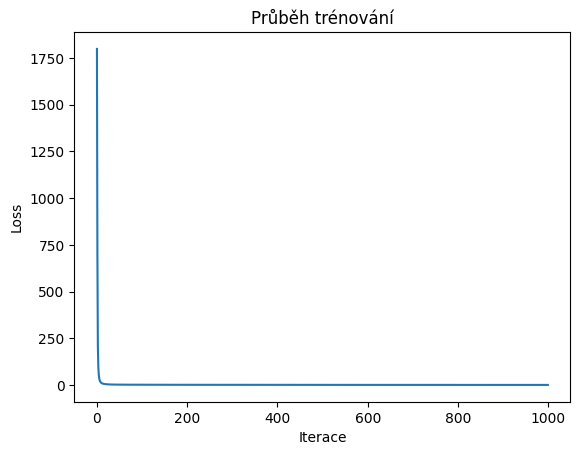

array([[-2.48173688, -3.17074585, -3.11561674, -2.61429537, 11.38237721],
       [ 7.25751351,  6.37338283, -6.94688463, -6.42021213, -0.26380394],
       [-5.63096499,  6.33791083, -6.94645792,  6.32008258, -0.08058507]])

In [112]:
theta = computeThetaGD(data, ref, plot_loss=True)
theta

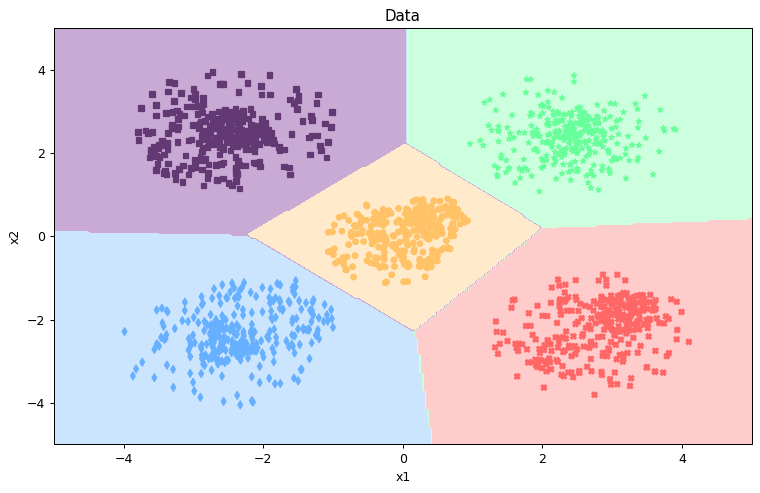

In [113]:
usu.drawSoftmax(data, ref, theta, softmax)


In [114]:
x_pred = np.array([[-3, -1],[ -3, 2],[ 3, -1],[ 3, 2],[0, 0]])
predict(x_pred,theta)


array([2, 3, 0, 1, 4])

# BONUS: Rozpoznávání číslovek (MNIST database) a mini-batch gradient descent

### **Dosáhněte accuracy (vypočtené na konci) alespoň 91 %.**

In [115]:
npzfile = np.load('data/data_07_mnist_train.npz') 

data = npzfile['data']
ref = npzfile['ref']

Prohlédněte si prvních 20 trénovacích vzorků:

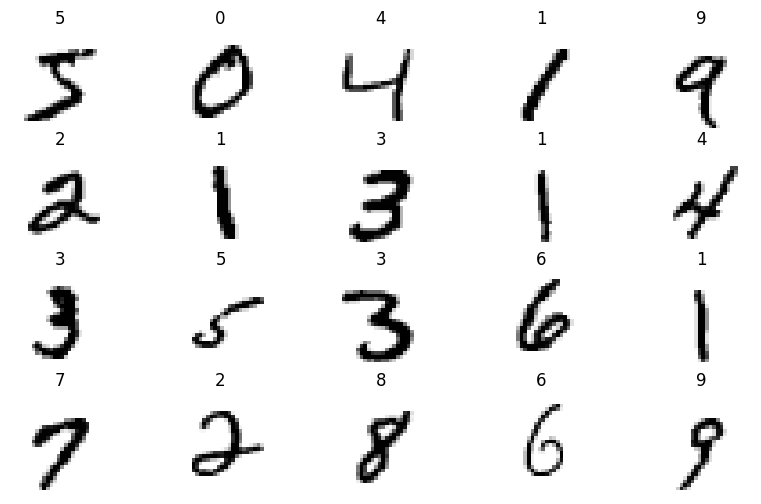

In [116]:
plt.figure(figsize=(10, 6))
for i in range(20):
    # Prevedeni linearizovych dat zpet na 2D matici.
    img = np.reshape(data[i], (28, 28))
    plt.subplot(4, 5, i+1)
    plt.imshow(img, "gray_r")
    plt.title(ref[i])
    plt.axis("off") 
plt.show()

Naimplementuje trénování modelu pomocí mini-batch gradient descent:

Mini-batch gradient descent vzhledem k množství dat zefektivní trénování (model se natrénuje rychleji a lépe zobecňuje).

Vyjděte z předchozí implementace `computeThetaGD` a upravte ji.

Počet iterací (u GD ekvivalentní průchodu všemi testovacími daty) bude nahrazen počtem tzv. epoch.

Jedna epocha probíhá následovně:
- Na začátku se náhodně zamíchají testovací data.
- Všechna testovací data se projdou po mini-batchích, jejichž délka je vždy rovna zadané `batch_size`. Na základě každého mini-batche se aktualizují váhy (u `computeThetaGD` se aktualizovaly váhy na základě všech dat). Pokud by na konci epochy zbyly vzorky, jejichž počet už je menší než `batch_size`, tak se přeskočí.
- Na konci epochy se spočítá loss na základě všech dat pro vizualizaci.

TIP: Vhodně normalizujte úpravu vah, aby její výsledná velikost nezávisela na `batch_size` a parametry `alpha` a `batch_size` jste mohli ladit nezávisle na sobě.

In [124]:
def computeThetaSGD(x, y, *, alpha, epochs, batch_size, plot_loss=False):
    # zafixovani nahody pri trenovani
    np.random.seed(0)

    # na konci kazde epochy vypoctete loss (ze vsech trenovacich vzorku) a zapiste ho na odpovidajici index v promenne
    loss = np.zeros(epochs)

    #################################################################
    # ZDE DOPLNIT

    x = np.c_[np.ones((x.shape[0], 1)), x]
    print(x.max())
    x = x / np.linalg.norm(x, axis=1, keepdims=True)
    print(x.max())
    theta = np.random.randn(x.shape[1], np.max(y) + 1) * 0.001
    new_y = np.zeros((y.shape[0], np.max(y) + 1))
    for i in range(y.shape[0]):
        new_y[i, y[i]] = 1
    y = new_y
    print(x.shape, theta.shape, y.shape)
    for i in range(epochs):
        print(f"Epocha {i+1}/{epochs}")
        indexes = np.arange(x.shape[0])
        indexes = np.random.permutation(indexes)
        new_x = x[indexes]
        new_y = y[indexes]
        for j in range(0, x.shape[0], batch_size):
            x_b = new_x[j:j+batch_size]
            y_b = new_y[j:j+batch_size]
            if x_b.shape[0] < batch_size:
                break
            theta = theta - alpha * x_b.T @ (softmax((x_b @ theta).T).T - y_b)
        loss[i] = -np.sum(new_y * np.log(softmax((new_x @ theta).T).T))
        
    
    #################################################################

    if plot_loss:
        show_loss(np.arange(epochs), loss, epoch=True)

    return theta


255.0
0.279026886376622
(60000, 785) (785, 10) (60000, 10)
Epocha 1/20
Epocha 2/20
Epocha 3/20
Epocha 4/20
Epocha 5/20
Epocha 6/20
Epocha 7/20
Epocha 8/20
Epocha 9/20
Epocha 10/20
Epocha 11/20
Epocha 12/20
Epocha 13/20
Epocha 14/20
Epocha 15/20
Epocha 16/20
Epocha 17/20
Epocha 18/20
Epocha 19/20
Epocha 20/20


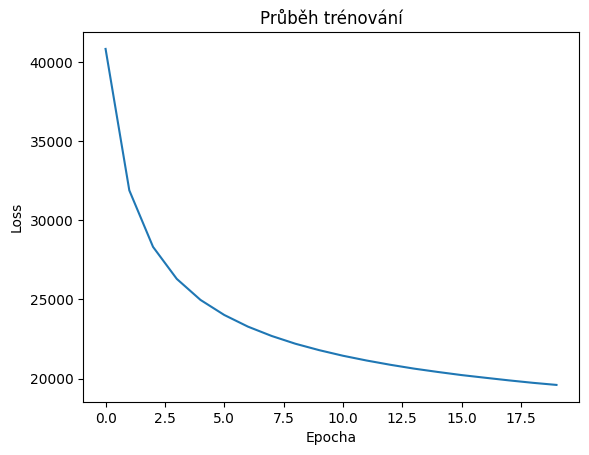

array([[-6.41372691e-03,  8.21070961e-03,  2.54913868e-03, ...,
         1.35717940e-02, -3.40858503e-02, -4.89093194e-03],
       [ 1.44043571e-04,  1.45427351e-03,  7.61037725e-04, ...,
        -2.05158264e-04,  3.13067702e-04, -8.54095739e-04],
       [-2.55298982e-03,  6.53618595e-04,  8.64436199e-04, ...,
        -1.87183850e-04,  1.53277921e-03,  1.46935877e-03],
       ...,
       [-1.49282498e-03, -2.38229840e-04, -1.27114134e-03, ...,
        -3.56723327e-04,  1.26309448e-03,  9.82297675e-05],
       [-5.78702967e-04, -1.29565356e-03,  8.18896155e-04, ...,
         2.19676213e-05, -2.26237591e-04,  8.00552643e-04],
       [ 2.58334164e-04,  1.34167906e-05, -9.56635808e-04, ...,
         1.67141696e-03,  1.42307301e-03, -5.66348461e-04]])

In [137]:
 # ZDE DOPLNIT hodnoty hyperparametrů (dostatečný model lze natrénovat během 5-10 sekund)
theta = computeThetaSGD(data, ref, batch_size=200, epochs=20, alpha=0.01, plot_loss=True)
#################################################################

theta

Prohlédněte si natrénované váhy (s výjimkou biasu):

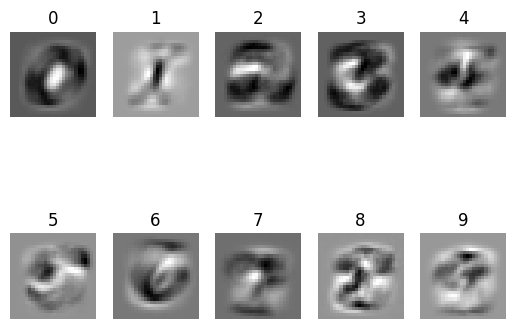

In [138]:
for i in range(theta.shape[1]):
    # Prvni vaha je bias, zbytek odpovida bodum v obrazu, takze je preskupime na 2D obraz.
    img = np.reshape(theta.T[i][1:], (28, 28))
    plt.subplot(2, 5, i+1)
    plt.imshow(img, "gray_r")
    plt.title(str(i))
    plt.axis("off") 
plt.show()

In [139]:
npzfile = np.load('data/data_07_mnist_test.npz') 

test_data = npzfile['data']
test_ref = npzfile['ref']

Otestujte prvních 20 testovacích vzorků:

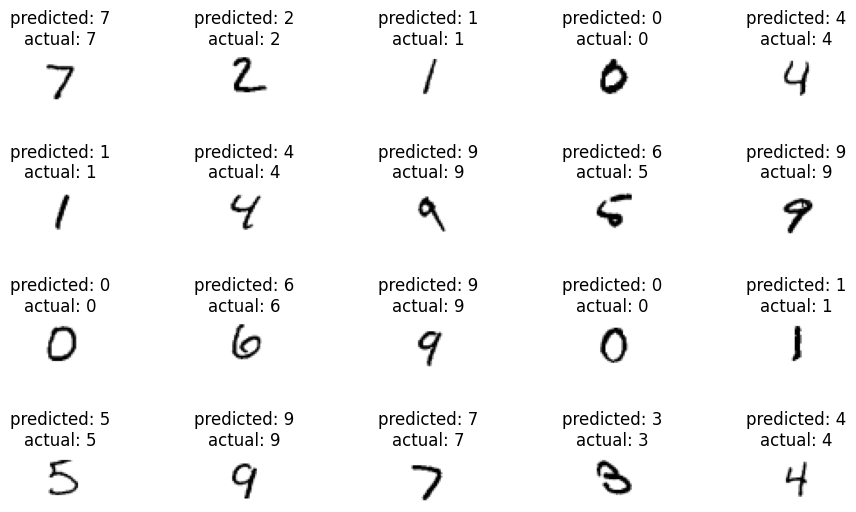

In [140]:
n = 20
x = test_data[:n, :]
y = test_ref[:n]

#################################################################
# ZDE DOPLNIT - Zjistete predikovane tridy pro `x`

y_pred = predict(x, theta)

#################################################################

plt.figure(figsize=(10, 6))
for i in range(n):
    # Prevedeni linearizovych dat zpet na 2D matici.
    img = np.reshape(x[i, :], (28, 28))
    plt.subplot(4, 5, i+1)
    plt.tight_layout(pad=3.0)
    plt.imshow(img, "gray_r")
    plt.title(f"predicted: {y_pred[i]}\nactual: {y[i]}")
    plt.axis("off")
plt.show()

Accuracy – přesnost natrénovaného modelu:

In [141]:
#################################################################
# ZDE DOPLNIT - Zjistete predikovane tridy pro vsechna testovaci data a procento spravne predikovanych dat (accuracy).

correct = predict(test_data, theta) == test_ref
accuracy = np.sum(correct) / test_data.shape[0]

#################################################################

print(f"Accuracy: {accuracy * 100}%")

Accuracy: 91.34%


Navíc: všimněte si, jak se mění grafy vah, když zvyšujete/snižujete batch size.